<a href="https://colab.research.google.com/github/DanielHevdeli/hafifot-tiug/blob/annotator-agreement/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import snapshot_download

# This downloads everything to a folder named 'c14_data'
snapshot_download(
    repo_id="js1699344/c14_articles",
    repo_type="dataset",
    local_dir="c14_data"
)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import BertTokenizer, AutoTokenizer

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [5]:
data = pd.read_json('c14_data/raw/articles_clean.jsonl', lines=True)
metadata = pd.read_csv('c14_data/raw/articles_metadata.csv')
metadata.head()

,id,date,wordsCount,author,archive_ids
0,1422673,2026-01-07 22:26,259,דור אזרד,"119546,998,977"
1,1415003,2025-12-31 00:41,151,אדם מיכלשווילי,"119546,998,977"
2,1333768,2025-10-01 00:55,423,אדם מיכלשווילי,"119546,998,977"
3,1184238,2025-04-13 20:13,222,דור אזרד,"119546,998,977"
4,1162964,2025-03-29 20:20,291,דור אזרד,"119546,998,977"


In [6]:
data.head()

,source,date,article_id,length,author,text
0,c14,2025-12-31 00:41:00,1415003,906,אדם מיכלשווילי,"לאחר כמעט שלוש שנים בלי משחק אירופי ביתי, הפוע..."
1,c14,2026-01-07 22:26:00,1422673,1621,דור אזרד,"לוהטת: אחרי הניצחון האדיר על הפועל ת""א בליגה, ..."
2,c14,2026-01-03 22:28:00,1417789,1480,אדם מיכלשווילי,אווירת פלייאוף בתחילת ינואר: במפגש טעון שנערך ...
3,c14,2026-01-07 00:49:00,1421784,1788,דור אזרד,"משבר? תחשבו שוב. אחרי שני הפסדים רצופים, הפועל..."
4,c14,2026-01-03 19:29:00,1417649,898,אדם מיכלשווילי,מכבי תל אביב רשמה אמש (שישי) את אחד ההפסדים הכ...


In [7]:
print(f'Number of articles: {len(data)}')

Number of articles: 108836


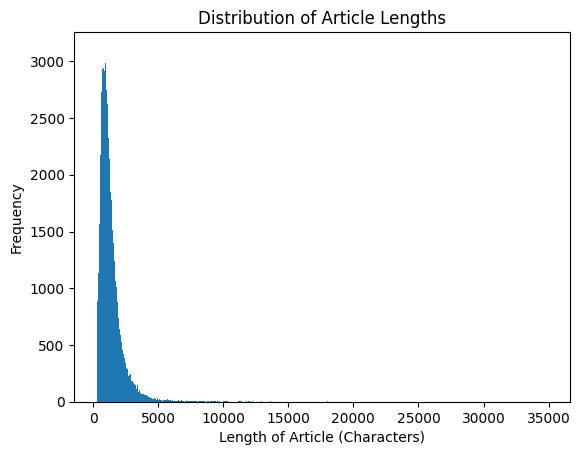

In [8]:
plt.hist(data['length'], bins=1000)
plt.xlabel('Length of Article (Characters)')
plt.ylabel('Frequency')
plt.title('Distribution of Article Lengths')
plt.show()

We can see that the majority of the articles are about 800-3000 in length

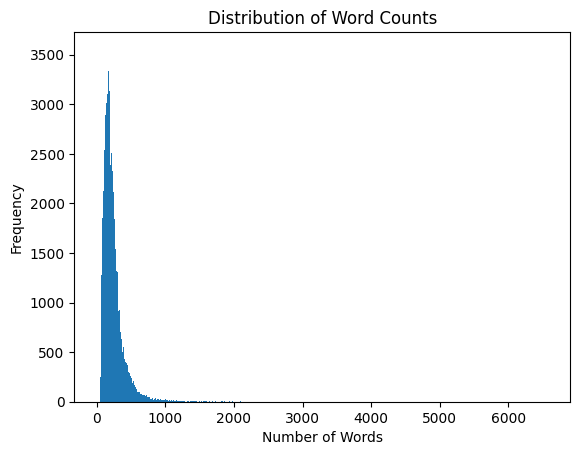

In [9]:
data['word_count'] = data['text'].apply(lambda x: len(str(x).split()))

plt.hist(data['word_count'], bins=1000)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts')
plt.show()

We can see that the distributions of chars and words among each one's scale are very similar (historgrams shape are very similar). Here, most of the articles contain 100-600 words

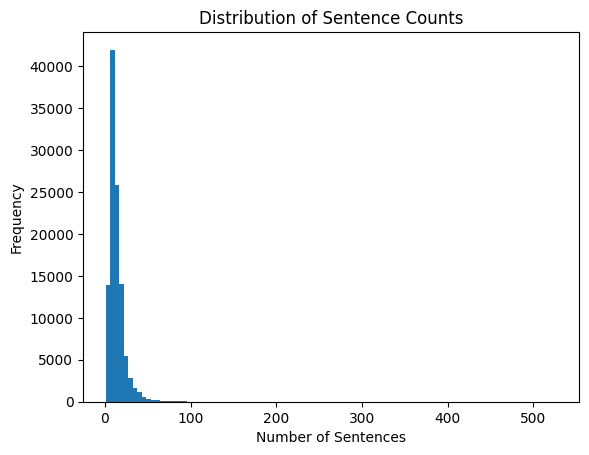

In [10]:
data['sentence_count'] = data['text'].apply(lambda x: len(str(x).split('.')))

plt.hist(data['sentence_count'], bins=100)
plt.xlabel('Number of Sentences')
plt.ylabel('Frequency')
plt.title('Distribution of Sentence Counts')
plt.show()

Most of the articles contain less than 50 sentences.

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (740 > 512). Running this sequence through the model will result in indexing errors


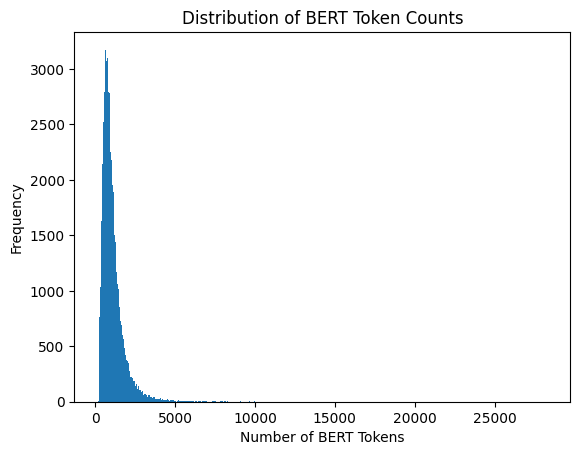

In [11]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def count_bert_tokens(text):
    if pd.isna(text):
        return 0
    tokens = tokenizer.tokenize(str(text))
    return len(tokens)

data['bert_token_count'] = data['text'].apply(count_bert_tokens)

plt.hist(data['bert_token_count'], bins=1000)
plt.xlabel('Number of BERT Tokens')
plt.ylabel('Frequency')
plt.title('Distribution of BERT Token Counts')
plt.show()

The distribution is almost identical to the char-level distribution, what implies that maybe the tokenizer didnt trained on a lot of hebrew text, what makes him a char-level tokenizer for hebrew. Lets check it!

In [12]:
arb_text = data['text'][0]
print("--------- Text ---------")
print(arb_text)
print("--------- Tokens ---------")
print(tokenizer.tokenize(arb_text))

--------- Text ---------
לאחר כמעט שלוש שנים בלי משחק אירופי ביתי, הפועל ירושלים חזרה הערב (שלישי) לארנה – וחגגה בענק עם ניצחון 69:105 על מנרסה, במסגרת היורוקאפ. הירושלמים רשמו את ניצחונהם התשיעי ברציפות במפעל ושיפרו את מאזנה ל-2:10, כשהיא מציגה מחצית שנייה אדירה של 20:64. החניכים של יונתן אלון, שמתקשים בשבועות האחרונים במשחקים ליגת העל, השאירו את הצרות מאחור, ולמרות פיגור 49:45 במחצית, חזרו מחדר ההלבשה עם הגנה משודרגת, התקפה שוטפת ושליטה מוחלטת שהובילה לבריחה חד-צדדית עד לסיום. קסיוס ווינסטון בלט עם 20 נקודות, ג'סטין סמית' וקאדין קרינגטון קלעו 15 כ"א, ג'ארד הארפר הוסיף 14 נקודות ו-7 אסיסטים, ויובל זוסמן תרם 14 נקודות נוספות. בסופו של דבר, שישה שחקנים באדום סיימו עם ספרות כפולות. עם תמיכת הקהל ביתי הנלהב, הפועל ירושלים חזרה להראות מה היא שווה והציגה את אחד המשחקים המרשימים שלה העונה. כעת, היא תנסה להמשיך את המומנטום גם בזירה המקומית, כאשר בשבת הקרובה תתארח אצל הפועל תל אביב למשחק צמרת לוהט במיוחד במסגרת ליגת ווינר סל.
--------- Tokens ---------
['ל', '##א', '##ח', '##ר', 'כ', '##מ', '#

We were right! So lets use a hebrew tokenizer

In [13]:
hebrew_tokenizer = AutoTokenizer.from_pretrained('onlplab/alephbert-base')

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (600 > 512). Running this sequence through the model will result in indexing errors


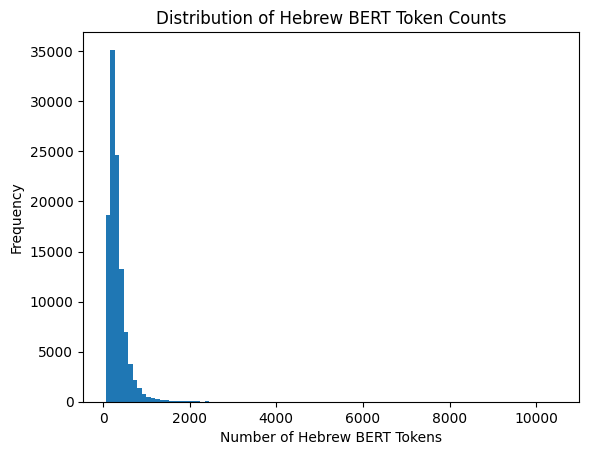

In [14]:

def count_hebrew_bert_tokens(text):
    if pd.isna(text):
        return 0
    return len(hebrew_tokenizer.encode(str(text), add_special_tokens=True))

data['hebrew_bert_token_count'] = data['text'].apply(count_hebrew_bert_tokens)

plt.hist(data['hebrew_bert_token_count'], bins=100)
plt.xlabel('Number of Hebrew BERT Tokens')
plt.ylabel('Frequency')
plt.title('Distribution of Hebrew BERT Token Counts')
plt.show()

This is much better and actually very similar to the words distribution. Lets check a few articles

In [15]:
def print_article_info(article_num):
    print('--------- Text ---------')
    print(data['text'][article_num])
    print('--------- Tokens (AlephBERT) ---------')
    print(hebrew_tokenizer.tokenize(data['text'][article_num]))
    print('--------------------------------------')
    print(f'Num of words: {data["word_count"][article_num]}')
    print(f'Num of AlephBERT tokens: {data["hebrew_bert_token_count"][article_num]}')

In [16]:
print_article_info(0)

--------- Text ---------
לאחר כמעט שלוש שנים בלי משחק אירופי ביתי, הפועל ירושלים חזרה הערב (שלישי) לארנה – וחגגה בענק עם ניצחון 69:105 על מנרסה, במסגרת היורוקאפ. הירושלמים רשמו את ניצחונהם התשיעי ברציפות במפעל ושיפרו את מאזנה ל-2:10, כשהיא מציגה מחצית שנייה אדירה של 20:64. החניכים של יונתן אלון, שמתקשים בשבועות האחרונים במשחקים ליגת העל, השאירו את הצרות מאחור, ולמרות פיגור 49:45 במחצית, חזרו מחדר ההלבשה עם הגנה משודרגת, התקפה שוטפת ושליטה מוחלטת שהובילה לבריחה חד-צדדית עד לסיום. קסיוס ווינסטון בלט עם 20 נקודות, ג'סטין סמית' וקאדין קרינגטון קלעו 15 כ"א, ג'ארד הארפר הוסיף 14 נקודות ו-7 אסיסטים, ויובל זוסמן תרם 14 נקודות נוספות. בסופו של דבר, שישה שחקנים באדום סיימו עם ספרות כפולות. עם תמיכת הקהל ביתי הנלהב, הפועל ירושלים חזרה להראות מה היא שווה והציגה את אחד המשחקים המרשימים שלה העונה. כעת, היא תנסה להמשיך את המומנטום גם בזירה המקומית, כאשר בשבת הקרובה תתארח אצל הפועל תל אביב למשחק צמרת לוהט במיוחד במסגרת ליגת ווינר סל.
--------- Tokens (AlephBERT) ---------
['לאחר', 'כמעט', 'שלוש', 'שני

In [17]:
print_article_info(10)

--------- Text ---------
הפועל תל אביב ספגה הערב (שלישי) הפסד מפתיע 93:80 לז'לגיריס קובנה, במשחק שנערך לראשונה העונה בהיכל מנורה מבטחים במסגרת היורוליג. אחרי פתיחה מבטיחה ויתרון דו ספרתי, הקבוצה של דימיטריס איטודיס לא הצליחה לשמור על המומנטום וירדה מנוצחת, מה שגרם לה לאבד את המקום הראשון בטבלת המפעל לולנסיה בסיום הסיבוב הראשון. האדומים נראו חדים ברבע הראשון ונהנו מתמיכת הקהל הביתי, אך החל מהרבע השני ז'לגיריס השתלטה על הקצב, בעיקר בזכות שליטה מוחלטת בריבאונד (21 בלבד להפועל מול 40 של האורחת) ותרומה התקפית משמעותית ממוזס רייט ונייג'ל וויליאמס-גוס. שלושה רבעים רצופים הסתיימו ביתרון ליטאי, וההבדל הורגש היטב בדקות ההכרעה, כשהאדומים נותרים כמעט ללא פתרונות. כריס ג'ונס סיים עם 18 נקודות, אלייז'ה בריאנט תרם 14, ודן אוטורו הוסיף 12, אך החיסרון של ואסיליה מיצ'יץ' ניכר, והאדומים לא הצליחו לייצר עצירות בהגנה. בצד השני כאמור, וויליאמס-גוס (17 נק'), רייט (15) ופרנסיסקו (13) הובילו קבוצה מאורגנת ומרוכזת שלא התרשמה מאווירה מחשמלת שסיפק הקהל האדום. למרות ההפסד, הפועל תל אביב מסיימת סיבוב ראשון מצוין עם

In [18]:
data[['length', 'word_count', 'sentence_count', 'bert_token_count', 'hebrew_bert_token_count']].describe()

,length,word_count,sentence_count,bert_token_count,hebrew_bert_token_count
count,108836.000000,108836.000000,108836.000000,108836.000000,108836.000000
mean,1357.751590,234.392977,14.031506,1105.013433,329.128119
std,1004.325179,174.981798,10.850376,818.538965,245.414529
min,300.000000,1.000000,1.000000,113.000000,60.000000
25%,788.000000,136.000000,8.000000,643.000000,190.000000
50%,1115.500000,192.000000,11.000000,905.000000,271.000000
75%,1611.000000,278.000000,16.000000,1308.000000,393.000000
max,34944.000000,6578.000000,527.000000,28330.000000,10473.000000


In [19]:
data['date'] = pd.to_datetime(data['date'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 108836 entries, 0 to 108835
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   source                   108836 non-null  str           
 1   date                     108836 non-null  datetime64[us]
 2   article_id               108836 non-null  int64         
 3   length                   108836 non-null  int64         
 4   author                   108836 non-null  str           
 5   text                     108836 non-null  str           
 6   word_count               108836 non-null  int64         
 7   sentence_count           108836 non-null  int64         
 8   bert_token_count         108836 non-null  int64         
 9   hebrew_bert_token_count  108836 non-null  int64         
dtypes: datetime64[us](1), int64(6), str(3)
memory usage: 8.3 MB


In [20]:
data['year'] = data['date'].dt.year
print(data['year'].value_counts().sort_index())

year
2018     1916
2019     4439
2020     6376
2021     8754
2022    15153
2023    15242
2024    19793
2025    29807
2026     7356
Name: count, dtype: int64


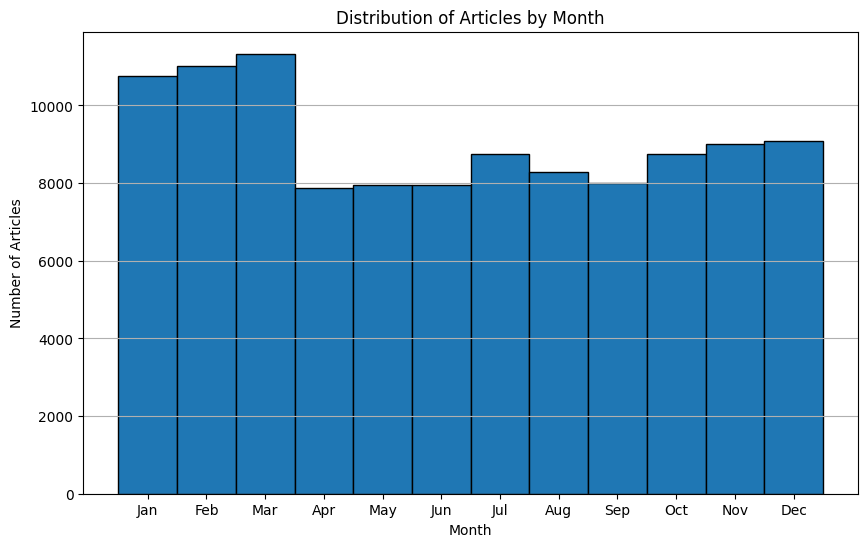

In [21]:
data['month'] = data['date'].dt.month

plt.figure(figsize=(10, 6))
plt.hist(data['month'], bins=range(1, 14), align='left', edgecolor='black')
plt.xlabel('Month')
plt.ylabel('Number of Articles')
plt.title('Distribution of Articles by Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y')
plt.show()

In [22]:
articles_per_month_year = data.groupby(['year', 'month']).size().unstack(fill_value=0)
print(articles_per_month_year)

month    1     2     3     4     5     6     7     8     9     10    11    12
year                                                                         
2018    401   480   476   479    80     0     0     0     0     0     0     0
2019    426   384   418   299   297   302   300   307   354   305   441   606
2020    586   445   498   368   345   303   573   689   450   636   673   810
2021    731   715   811   791   736   778   716   666   524   806   730   750
2022   1068   948  1325  1148  1407  1336  1292  1408  1410  1285  1433  1093
2023   1266  1270  1316  1035  1206  1091  1299  1339  1133  1717  1382  1188
2024   1268  1381  1459  1148  1075  1353  1862  1794  2050  1877  2145  2381
2025   2359  2670  3054  2615  2808  2794  2719  2088  2092  2132  2207  2269
2026   2665  2716  1975     0     0     0     0     0     0     0     0     0


In [23]:
earliest_date = data['date'].min()
latest_date = data['date'].max()

print(f"Earliest article date: {earliest_date}")
print(f"Latest article date: {latest_date}")

Earliest article date: 2018-01-01 00:17:00
Latest article date: 2026-03-22 17:11:00
